# RetinaUNet Synthetic Training Notebook

Train RetinaUNet on synthetic 2D medical images with GPU-aware CUDA AMP support and before/after segmentation visualization.

## 1. Environment Setup

Run the next cell in Google Colab to install PyHealth from the RetinaUNet feature branch.


In [145]:
# Colab-safe setup: remove stale checkout, clone fresh, and pin to known-good commit
!pip -q install --upgrade pip
!rm -rf /content/PyHealth
!git clone -q https://github.com/iamkishann/PyHealth.git /content/PyHealth

# Pin to commit that includes class_loss/bbox_loss/seg_loss in RetinaUNet.forward
KNOWN_GOOD_COMMIT = "fd209d5"
!git -C /content/PyHealth checkout -q {KNOWN_GOOD_COMMIT}

# Reinstall from the pinned checkout so imports match current repo state.
!pip -q uninstall -y pyhealth
!pip -q install --no-deps -e /content/PyHealth

# Print evidence from the actual file on disk.
!git -C /content/PyHealth rev-parse --short HEAD
!grep -n 'results\["class_loss"\]\|results\["bbox_loss"\]\|results\["seg_loss"\]' /content/PyHealth/pyhealth/models/retina_unet.py

print("Fresh-cloned and installed pinned PyHealth from /content/PyHealth (editable).")
print("Restart runtime once, then run all cells from the top.")

  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Installing backend dependencies ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for pyhealth (pyproject.toml) ... done
fd209d5
1728:            results["class_loss"] = class_loss
1729:            results["bbox_loss"] = bbox_loss
1730:            results["seg_loss"] = seg_loss
Fresh-cloned and installed pinned PyHealth from /content/PyHealth (editable).
Restart runtime once, then run all cells from the top.


In [8]:
# 2. Imports, extra deps, and seeding
!pip -q install --no-deps litdata distributed tblib zict sortedcontainers mne rdkit lightning_utilities boto3 botocore s3transfer jmespath

import os
import sys
import random
import inspect
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.optim as optim
from torch.cuda.amp import autocast, GradScaler

if os.path.exists('/content/PyHealth'):
    sys.path.insert(0, '/content/PyHealth')
else:
    sys.path.insert(0, os.path.abspath('../'))

from pyhealth.models import RetinaUNet
import pyhealth
# Compatible imports across PyHealth package variants
try:
    from pyhealth.datasets import create_sample_dataset, get_dataloader
except ImportError:
    from pyhealth.datasets.sample_dataset import create_sample_dataset
    from pyhealth.datasets.utils import get_dataloader

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)
if device.type == 'cuda':
    print('GPU:', torch.cuda.get_device_name(0))
    torch.backends.cudnn.benchmark = True

Device: cuda
GPU: NVIDIA L4


In [33]:
import sys
import os
sys.path.insert(0, os.path.abspath('../'))

import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import pandas as pd
from pathlib import Path
from typing import Optional, Tuple
from torch.utils.data import Dataset, DataLoader

In [34]:
def create_dummy_image_and_mask(img_size=(320, 320), num_objects=1, foreground_margin=50):
    """Create a synthetic 2D image and binary mask."""
    height, width = img_size
    # Clamp margin so it's always valid for the given image size
    margin = min(foreground_margin, height // 4, width // 4)
    image = np.random.rand(height, width).astype(np.float32)
    mask = np.zeros((height, width), dtype=np.uint8)
    for _ in range(num_objects):
        center_y = np.random.randint(margin, height - margin)
        center_x = np.random.randint(margin, width  - margin)
        radius = np.random.randint(5, max(6, min(20, margin // 2)))
        yy, xx = np.ogrid[:height, :width]
        circle = (xx - center_x) ** 2 + (yy - center_y) ** 2 <= radius ** 2
        image[circle] += 0.3
        mask[circle] = 1
    return np.clip(image, 0, 1), mask

In [35]:
def generate_dummy_dataset(output_dir, num_train_samples=2, num_val_samples=1,
                           img_size=(320, 320), objects_per_image=1):
    """Generate a small file-based dataset compatible with LIDCDataLoader."""
    output_path = Path(output_dir)
    output_path.mkdir(parents=True, exist_ok=True)
    records = []

    def _write_split(split, sample_count, prefix):
        for idx in range(sample_count):
            image, mask = create_dummy_image_and_mask(img_size=img_size, num_objects=objects_per_image)
            patient_id = f"{prefix}_{idx:04d}"
            img_path  = output_path / f"{patient_id}_slice_0_img.npy"
            mask_path = output_path / f"{patient_id}_slice_0_mask.npy"
            np.save(img_path, image)
            np.save(mask_path, mask)
            records.append({
                "patient_id": patient_id, "slice": 0,
                "image_path": str(img_path), "mask_path": str(mask_path),
                "has_nodule": int(mask.max() > 0), "split": split,
            })

    _write_split("train", num_train_samples, "DUMMY")
    _write_split("val",   num_val_samples,   "DUMMY_VAL")
    pd.DataFrame(records).to_csv(output_path / "metadata.csv", index=False)
    print(f"Dataset created: {len(records)} samples in {output_dir}")
    return output_dir

In [36]:
class LIDCDataset(Dataset):
    """
    LIDC-IDRI-style dataset loader.

    Expects data_dir to contain:
      <patient_id>_slice_<N>_img.npy
      <patient_id>_slice_<N>_mask.npy
      metadata.csv

    Returns batches with keys 'image' and 'seg' so they can be passed
    directly to RetinaUNet via Trainer(**batch) or model(**batch).
    """

    def __init__(self, data_dir, metadata_file='metadata.csv', split='train',
                 normalize=True, target_size=None, augmentation=False):
        self.data_dir    = Path(data_dir)
        self.split       = split
        self.normalize   = normalize
        self.target_size = target_size
        self.augmentation = augmentation

        meta_path = self.data_dir / metadata_file
        self.metadata = pd.read_csv(meta_path) if meta_path.exists() else self._scan_dir()

        if 'split' in self.metadata.columns:
            self.metadata = self.metadata[self.metadata['split'] == split].reset_index(drop=True)
        self.samples = self.metadata.to_dict('records')

    def _scan_dir(self):
        records = []
        for npy in self.data_dir.glob('*_img.npy'):
            mask_path = npy.parent / npy.name.replace('_img.npy', '_mask.npy')
            if mask_path.exists():
                parts = npy.stem.split('_')
                records.append({
                    'patient_id': '_'.join(parts[:-3]),
                    'slice': int(parts[-2]),
                    'image_path': str(npy),
                    'mask_path': str(mask_path),
                    'has_nodule': int(np.load(mask_path).max() > 0),
                })
        return pd.DataFrame(records)

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        s = self.samples[idx]
        image = np.load(s['image_path']).astype(np.float32)
        seg   = np.load(s['mask_path']).astype(np.float32)

        # Ensure 2-D
        if image.ndim == 3:
            image = image[0] if image.shape[0] == 1 else image[:, :, 0]
        if seg.ndim == 3:
            seg   = seg[0]   if seg.shape[0]   == 1 else seg[:, :, 0]

        if self.normalize:
            image = np.clip(image, -1200, 600)
            std = image.std()
            image = (image - image.mean()) / std if std > 0 else image

        if self.target_size:
            from scipy.ndimage import zoom
            h, w = image.shape
            th, tw = self.target_size
            image = zoom(image, (th / h, tw / w), order=1)
            seg   = zoom(seg,   (th / h, tw / w), order=0)

        if self.augmentation and self.split == 'train':
            if np.random.rand() > 0.5:
                image, seg = np.fliplr(image), np.fliplr(seg)
            if np.random.rand() > 0.5:
                image, seg = np.flipud(image), np.flipud(seg)

        return {
            'image': torch.from_numpy(np.ascontiguousarray(image)).unsqueeze(0).float(),
            'seg':   torch.from_numpy(np.ascontiguousarray(seg)).long(),
        }

In [38]:
class LIDCDataLoader:
    """Factory for creating train/val/test DataLoaders from a LIDC-style directory."""

    @staticmethod
    def create_dataloaders(data_dir, batch_size=4, num_workers=0, target_size=None,
                           train_split=0.7, val_split=0.15, seed=42):
        np.random.seed(seed)
        torch.manual_seed(seed)

        train_ds = LIDCDataset(data_dir, split='train', normalize=True,
                               target_size=target_size, augmentation=True)
        val_ds   = LIDCDataset(data_dir, split='val',   normalize=True,
                               target_size=target_size, augmentation=False)
        test_ds  = LIDCDataset(data_dir, split='test',  normalize=True,
                               target_size=target_size, augmentation=False)

        # Fallback: random split when metadata has no 'split' column
        if len(train_ds) == 0:
            all_ds = LIDCDataset(data_dir, normalize=True, target_size=target_size)
            n_train = int(len(all_ds) * train_split)
            n_val   = int(len(all_ds) * val_split)
            idx = np.random.permutation(len(all_ds))
            train_ds = torch.utils.data.Subset(all_ds, idx[:n_train])
            val_ds   = torch.utils.data.Subset(all_ds, idx[n_train:n_train + n_val])
            test_ds  = torch.utils.data.Subset(all_ds, idx[n_train + n_val:])

        return {
            'train': DataLoader(train_ds, batch_size=batch_size, shuffle=True,
                                num_workers=num_workers, pin_memory=False),
            'val':   DataLoader(val_ds,   batch_size=batch_size, shuffle=False,
                                num_workers=num_workers, pin_memory=False),
            'test':  DataLoader(test_ds,  batch_size=batch_size, shuffle=False,
                                num_workers=0,           pin_memory=False),
        }

In [39]:
from pyhealth.datasets import create_sample_dataset
from pyhealth.models import RetinaUNet

dummy_data_dir = './dummy_data_test'
checkpoint_dir = './checkpoints_test'
log_dir        = './logs_test'

# Generate synthetic disk data
generate_dummy_dataset(
    output_dir=dummy_data_dir,
    num_train_samples=500,
    num_val_samples=100,
    img_size=(320, 320),
    objects_per_image=1,
)

# Build a minimal PyHealth SampleDataset for model schema initialisation
init_samples = [
    {"patient_id": f"init-{i}", "visit_id": "v0",
     "image": np.zeros((1, 64, 64), dtype=np.float32).tolist(),
     "seg":   np.zeros((64, 64),    dtype=np.int64).tolist()}
    for i in range(2)
]
init_dataset = create_sample_dataset(
    samples=init_samples,
    input_schema={"image": "tensor", "seg": "tensor"},
    output_schema={"seg": "tensor"},
    dataset_name="retina_unet_demo",
)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Match sample notebook's "smaller for testing" backbone/head sizing.
TEST_FPN_BASE_CHANNELS = 32
TEST_FPN_OUT_CHANNELS = 96
TEST_RPN_HIDDEN_CHANNELS = 128

model = RetinaUNet(
    dataset=init_dataset,
    feature_key="image",
    seg_label_key="seg",
    num_seg_classes=2,
    head_classes=2,
    dim=2,
    fpn_base_channels=TEST_FPN_BASE_CHANNELS,
    fpn_out_channels=TEST_FPN_OUT_CHANNELS,
    rpn_hidden_channels=TEST_RPN_HIDDEN_CHANNELS,
)
print(
    f"RetinaUNet ready on {device} | "
    f"fpn_base_channels={TEST_FPN_BASE_CHANNELS}, "
    f"fpn_out_channels={TEST_FPN_OUT_CHANNELS}, "
    f"rpn_hidden_channels={TEST_RPN_HIDDEN_CHANNELS}"
)


Dataset created: 600 samples in ./dummy_data_test
RetinaUNet ready on cuda | fpn_base_channels=32, fpn_out_channels=96, rpn_hidden_channels=128


In [41]:
import logging
from dataclasses import dataclass
import torch.optim as optim
from torch.amp import autocast, GradScaler


@dataclass
class SimpleTrainer:
    history: list
    best_val_loss: float
    best_checkpoint_path: str


def train_model(
    data_dir,
    checkpoint_dir,
    log_dir,
    model_instance=None,
    num_epochs=15,
    batch_size=32,
    lr=1e-3,
    num_workers=0,
    dim=2,
    target_size=(320, 320),
):
    del log_dir, dim  # Kept for API compatibility with sample notebook.

    global dataloaders
    dataloaders = LIDCDataLoader.create_dataloaders(
        data_dir,
        batch_size=batch_size,
        num_workers=num_workers,
        target_size=target_size,
    )
    train_loader = dataloaders["train"]
    val_loader = dataloaders["val"]

    model_train = (model if model_instance is None else model_instance).to(device)
    optimizer = optim.Adam(model_train.parameters(), lr=lr)
    scaler = GradScaler('cuda' if device.type == 'cuda' else 'cpu')
    use_amp = device.type == "cuda"

    loss_keys = ["loss", "class_loss", "bbox_loss", "seg_loss"]
    history = []

    logger = logging.getLogger("training")
    logger.setLevel(logging.INFO)
    logger.propagate = False
    logger.handlers.clear()
    handler = logging.StreamHandler()
    handler.setFormatter(logging.Formatter("%(asctime)s - training - %(levelname)s - %(message)s"))
    logger.addHandler(handler)

    checkpoint_path = Path(checkpoint_dir)
    checkpoint_path.mkdir(parents=True, exist_ok=True)
    best_val_loss = float("inf")
    best_ckpt = str(checkpoint_path / "retina_unet_best.pt")

    for epoch in range(1, num_epochs + 1):
        logger.info("")
        print(f"--- Epoch {epoch}/{num_epochs} ---")

        model_train.train()
        t_sums = {k: 0.0 for k in loss_keys}
        t_count = 0
        for batch in train_loader:
            seg_key = "seg" if "seg" in batch else "mask"
            optimizer.zero_grad(set_to_none=True)

            with autocast(device_type=device.type, enabled=use_amp):
                out = model_train(
                    image=batch["image"].to(device),
                    seg=batch[seg_key].to(device),
                    return_aux=True,
                )

            scaler.scale(out["loss"]).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model_train.parameters(), 5.0)
            scaler.step(optimizer)
            scaler.update()

            for k in loss_keys:
                t_sums[k] += out[k].item()
            t_count += 1
        t_avg = {k: t_sums[k] / max(t_count, 1) for k in loss_keys}

        model_train.eval()
        v_sums = {k: 0.0 for k in loss_keys}
        v_count = 0
        with torch.no_grad():
            for batch in val_loader:
                seg_key = "seg" if "seg" in batch else "mask"
                with autocast(device_type=device.type, enabled=use_amp):
                    out = model_train(
                        image=batch["image"].to(device),
                        seg=batch[seg_key].to(device),
                        return_aux=True,
                    )
                for k in loss_keys:
                    v_sums[k] += out[k].item()
                v_count += 1
        v_avg = {k: v_sums[k] / max(v_count, 1) for k in loss_keys}

        logger.info(
            f"Train - total_loss: {t_avg['loss']:.4f}, class_loss: {t_avg['class_loss']:.4f}, "
            f"bbox_loss: {t_avg['bbox_loss']:.4f}, seg_loss: {t_avg['seg_loss']:.4f}"
        )
        logger.info(
            f"Val   - total_loss: {v_avg['loss']:.4f}, class_loss: {v_avg['class_loss']:.4f}, "
            f"bbox_loss: {v_avg['bbox_loss']:.4f}, seg_loss: {v_avg['seg_loss']:.4f}"
        )

        if v_avg["loss"] < best_val_loss:
            best_val_loss = v_avg["loss"]
            torch.save(model_train.state_dict(), best_ckpt)
            logger.info(f"Saved best checkpoint with val_loss: {best_val_loss:.4f}")

        history.append({"epoch": epoch, "train": t_avg, "val": v_avg})

    logger.info("Training complete!")
    return model_train, SimpleTrainer(history=history, best_val_loss=best_val_loss, best_checkpoint_path=best_ckpt)


model_trained, trainer = train_model(
    data_dir=dummy_data_dir,
    checkpoint_dir=checkpoint_dir,
    log_dir=log_dir,
    model_instance=model,
    num_epochs=30,
    batch_size=16,
    lr=1e-3,
    num_workers=0,
    dim=2,
    target_size=(320, 320),
)

model = model_trained
history = trainer.history
val_loader = dataloaders["val"]


2026-04-12 21:33:29,963 - training - INFO - 


--- Epoch 1/30 ---


2026-04-12 21:36:38,651 - training - INFO - Train - total_loss: 0.8387, class_loss: 0.7125, bbox_loss: 0.0142, seg_loss: 0.2238
2026-04-12 21:36:38,652 - training - INFO - Val   - total_loss: 0.7184, class_loss: 0.6951, bbox_loss: 0.0114, seg_loss: 0.0238
2026-04-12 21:36:38,730 - training - INFO - Saved best checkpoint with val_loss: 0.7184
2026-04-12 21:36:38,730 - training - INFO - 


--- Epoch 2/30 ---


2026-04-12 21:36:57,370 - training - INFO - Train - total_loss: 0.7184, class_loss: 0.6950, bbox_loss: 0.0108, seg_loss: 0.0252
2026-04-12 21:36:57,371 - training - INFO - Val   - total_loss: 0.7112, class_loss: 0.6942, bbox_loss: 0.0092, seg_loss: 0.0155
2026-04-12 21:36:57,449 - training - INFO - Saved best checkpoint with val_loss: 0.7112
2026-04-12 21:36:57,450 - training - INFO - 


...

2026-04-12 21:44:33,183 - training - INFO - Train - total_loss: 0.3086, class_loss: 0.3021, bbox_loss: 0.0010, seg_loss: 0.0111
2026-04-12 21:44:33,184 - training - INFO - Val   - total_loss: 0.3001, class_loss: 0.2940, bbox_loss: 0.0008, seg_loss: 0.0108
2026-04-12 21:44:33,257 - training - INFO - Saved best checkpoint with val_loss: 0.3001
2026-04-12 21:44:33,258 - training - INFO - 


--- Epoch 29/30 ---


2026-04-12 21:44:50,396 - training - INFO - Train - total_loss: 0.3049, class_loss: 0.2979, bbox_loss: 0.0011, seg_loss: 0.0116
2026-04-12 21:44:50,396 - training - INFO - Val   - total_loss: 0.3093, class_loss: 0.3027, bbox_loss: 0.0013, seg_loss: 0.0107
2026-04-12 21:44:50,397 - training - INFO - 


--- Epoch 30/30 ---


2026-04-12 21:45:07,414 - training - INFO - Train - total_loss: 0.3038, class_loss: 0.2972, bbox_loss: 0.0011, seg_loss: 0.0111
2026-04-12 21:45:07,415 - training - INFO - Val   - total_loss: 0.3295, class_loss: 0.3221, bbox_loss: 0.0020, seg_loss: 0.0110
2026-04-12 21:45:07,415 - training - INFO - Training complete!


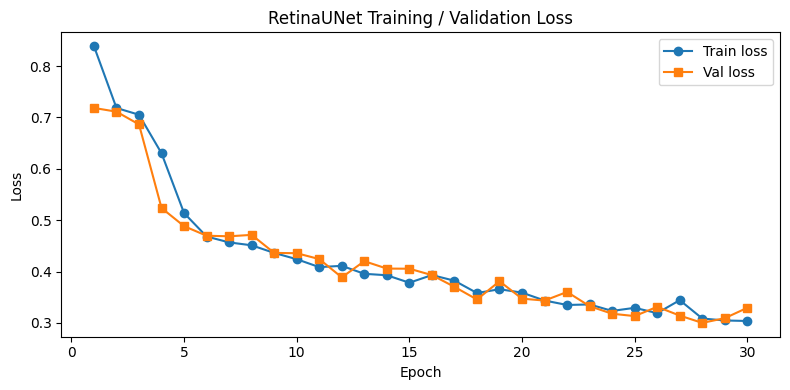

In [42]:
epochs      = [h['epoch']               for h in history]
train_total = [h['train']['loss']        for h in history]
val_total   = [h['val']['loss']          for h in history]

plt.figure(figsize=(8, 4))
plt.plot(epochs, train_total, marker='o', label='Train loss')
plt.plot(epochs, val_total,   marker='s', label='Val loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('RetinaUNet Training / Validation Loss')
plt.legend()
plt.tight_layout()
plt.show()

In [43]:
# Grab one validation batch for inspection and visualization
test = next(iter(dataloaders["val"]))
img = test["image"]   # (B, 1, H, W)
seg_key = "seg" if "seg" in test else "mask"
seg_gt = test[seg_key]  # (B, H, W)
print(f"Batch: {img.shape}, seg: {seg_gt.shape}")


Batch: torch.Size([16, 1, 320, 320]), seg: torch.Size([16, 320, 320])


In [44]:
test.keys()


dict_keys(['image', 'seg'])

In [45]:
# Run inference on the test batch defined above
model_trained.eval()

images = test["image"].to(device)
seg_key = "seg" if "seg" in test else "mask"
seg = test[seg_key].to(device)

with torch.no_grad():
    outputs = model_trained(image=images, seg=seg, return_aux=True)

print("Output keys:      ", list(outputs.keys()))
print("Detections shape: ", outputs["detections"].shape)


Output keys:       ['logit', 'y_prob', 'y_true', 'class_loss', 'bbox_loss', 'seg_loss', 'total_loss', 'loss', 'seg_preds', 'class_logits', 'bbox_deltas', 'detections', 'boxes', 'monitor_values']
Detections shape:  torch.Size([26, 7])


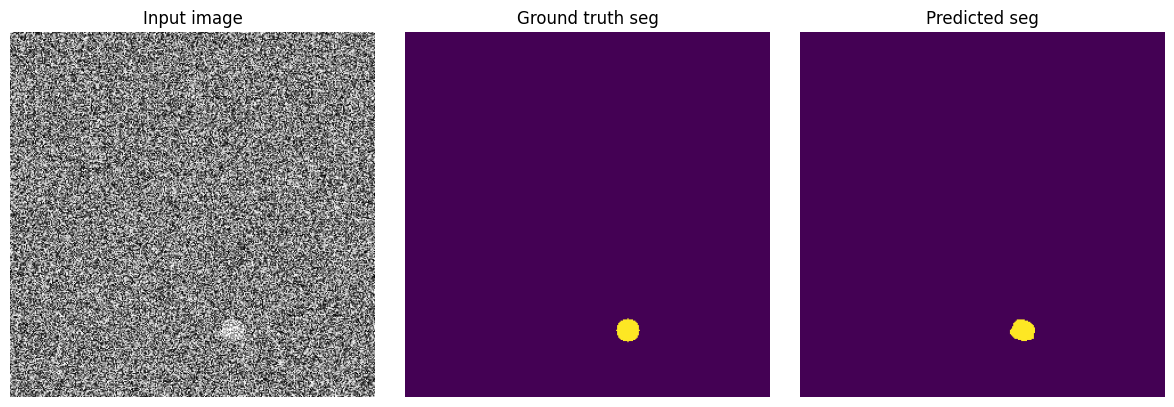

In [46]:
# Before/after segmentation visualization (GT vs prediction)
def show_segmentation_before_after(images, seg_gt_batch, model_outputs, sample_idx=0):
    img_np = images[sample_idx, 0].detach().cpu().numpy()

    gt = seg_gt_batch
    if gt.ndim == 4:
        gt = gt[:, 0]
    gt_np = gt[sample_idx].detach().cpu().numpy()

    pred = model_outputs.get("seg_preds")
    if pred is None:
        pred = torch.argmax(model_outputs["logit"], dim=1)
    if pred.ndim == 4:
        pred = pred[:, 0] if pred.shape[1] == 1 else torch.argmax(pred, dim=1)
    pred_np = pred[sample_idx].detach().cpu().numpy()

    fig, ax = plt.subplots(1, 3, figsize=(12, 4))
    ax[0].imshow(img_np, cmap="gray")
    ax[0].set_title("Input image")
    ax[0].axis("off")

    ax[1].imshow(gt_np, cmap="viridis")
    ax[1].set_title("Ground truth seg")
    ax[1].axis("off")

    ax[2].imshow(pred_np, cmap="viridis")
    ax[2].set_title("Predicted seg")
    ax[2].axis("off")

    plt.tight_layout()
    plt.show()

show_segmentation_before_after(images=test["image"], seg_gt_batch=seg, model_outputs=outputs, sample_idx=0)

In [47]:
img = test["image"]#[0]

In [48]:
seg_gt_np = test["seg"][0]  # (H, W) ground-truth segmentation mask


In [49]:
print("Batch keys:", list(test.keys()))


Batch keys: ['image', 'seg']


In [50]:
img.shape

torch.Size([16, 1, 320, 320])

In [51]:
seg_gt_np.shape


torch.Size([320, 320])

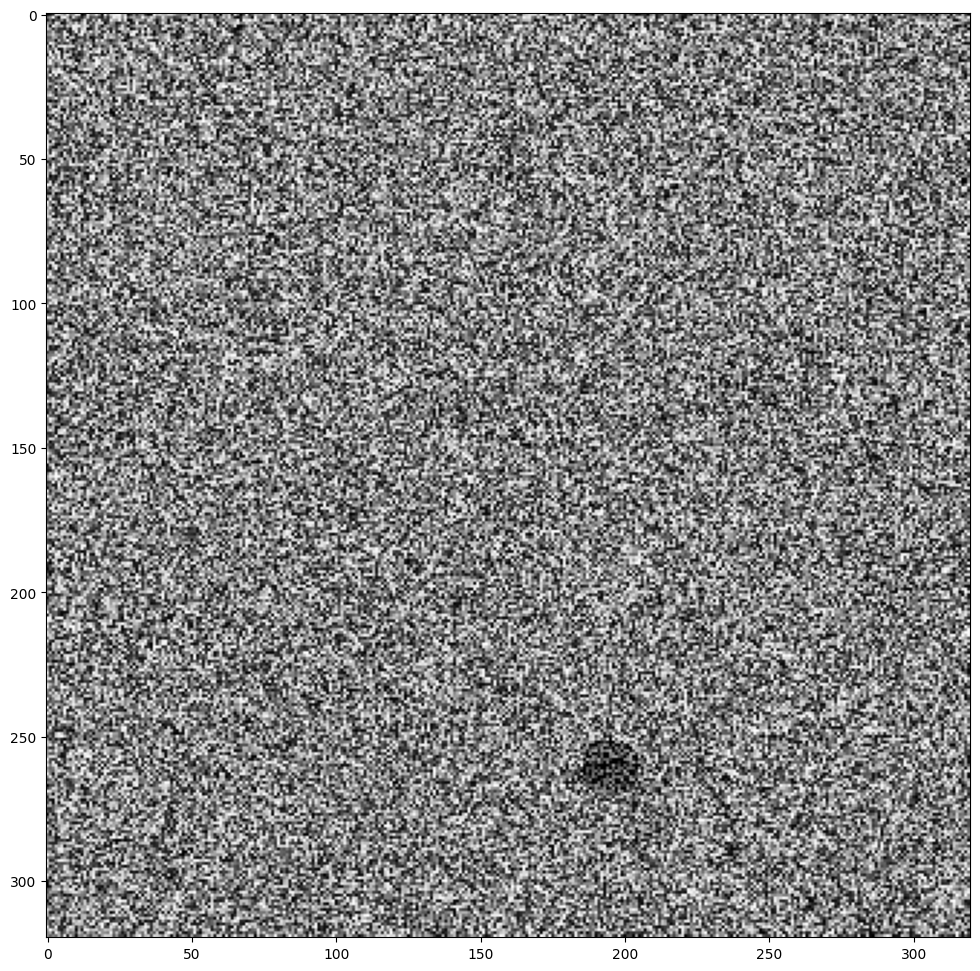

In [52]:
plt.figure(figsize=(12, 12))

plt.imshow(img[0][0], cmap='gray_r') #viridis
# plt.imshow(mask[0], cmap='BuGn_r', alpha=0.3) # Overlay mask with 50% opacity

In [53]:
outputs["detections"]#.detach().cpu().numpy()

tensor([[251.4521, 187.1882, 276.2426, 212.0073,   0.0000,   1.0000,   0.9998],
        [  0.0000,   0.0000,   4.8612,   4.7964,   0.0000,   1.0000,   0.3599],
        [  0.0000,   7.1412,   4.7403,  16.8859,   0.0000,   1.0000,   0.3599],
        [  0.0000,  19.1219,   4.7481,  28.8676,   0.0000,   1.0000,   0.3599],
        [  0.0000,  31.1225,   4.7464,  40.8676,   0.0000,   1.0000,   0.3599],
        [  0.0000,  43.1194,   4.7459,  52.8648,   0.0000,   1.0000,   0.3599],
        [  0.0000,  55.1283,   4.7496,  64.8757,   0.0000,   1.0000,   0.3599],
        [  0.0000,  67.1271,   4.7479,  76.8691,   0.0000,   1.0000,   0.3599],
        [  0.0000,  79.1263,   4.7626,  88.8730,   0.0000,   1.0000,   0.3599],
        [  0.0000,  91.1239,   4.7446, 100.8667,   0.0000,   1.0000,   0.3599],
        [106.5204,  98.5349, 132.9678, 124.9741,   1.0000,   1.0000,   1.0000],
        [ 71.1693,  65.8641, 121.8337,  94.4294,   1.0000,   1.0000,   0.3621],
        [ 81.3977, 237.5394,  94.6070, 2

In [54]:
import matplotlib.patches as patches

def visualize_retina_outputs(images, detections, threshold=0.5):
    """
    images: (Batch, Channel, Height, Width) - The input tensor
    detections: (N, 7) - The output tensor [y1, x1, y2, x2, batch_id, class_id, score]
    """

    # 1. Convert images to Numpy for plotting
    # Permute to (Batch, Height, Width, Channel) for Matplotlib
    images_np = images.permute(0, 2, 3, 1).cpu().numpy()

    # If image is grayscale (1 channel), squeeze it to 2D
    if images_np.shape[-1] == 1:
        images_np = images_np.squeeze(-1)

    batch_size = images.shape[0]

    # Create a figure with subplots for each image in the batch
    fig, axes = plt.subplots(1, batch_size, figsize=(12, 6))
    if batch_size == 1: axes = [axes] # Handle single image case

    for b in range(batch_size):
        ax = axes[b]

        # Show the Image
        ax.imshow(images_np[b], cmap='gray')
        ax.set_title(f"Batch Image #{b}")
        ax.axis('off')

        # 2. Filter Detections for this Batch ID (Column 4)
        # We only want rows where batch_id == b
        mask = detections[:, 4] == b
        batch_dets = detections[mask]

        for row in batch_dets:
            y1, x1, y2, x2, batch_id, class_id, score = row.tolist()

            # 3. Score Threshold Filter
            if score < threshold:
                continue

            # 4. Coordinate Transformation (Matrix -> Cartesian)
            # Model output: y1 (top), x1 (left), y2 (bottom), x2 (right)
            # Matplotlib Rect: (x_lower_left, y_lower_left), width, height
            width = x2 - x1
            height = y2 - y1

            # Create a Rectangle patch
            # Use x1 for left edge, y1 for top edge (for text), and y2 for bottom-left of rectangle
            rect = patches.Rectangle(
                (x1, y1), width, height, # x1, y1 is top-left in image coords
                linewidth=2, edgecolor='red', facecolor='none'
            )

            # Add patch to the plot
            ax.add_patch(rect)

            # Add Label (Class + Score)
            label_text = f"Cls {int(class_id)}: {score:.2f}"
            ax.text(
                x1, y1 - 5, label_text,
                color='white', fontsize=8, backgroundcolor='red'
            )

    plt.tight_layout()
    plt.show()

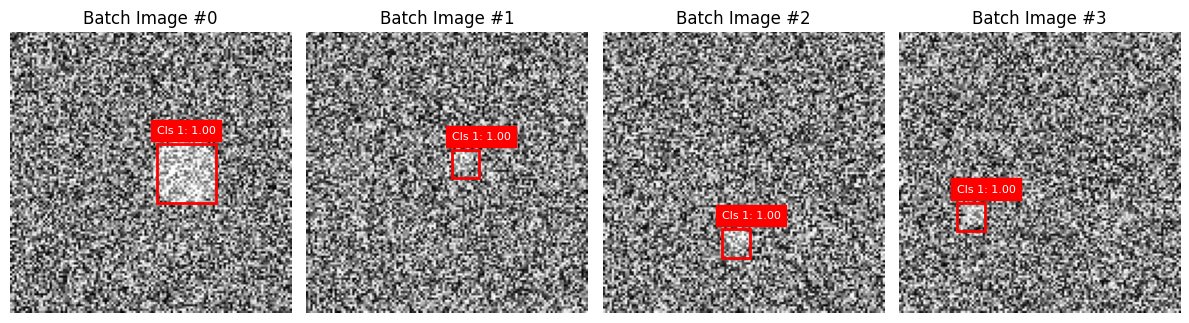

In [29]:
# Select the first 4 images from the batch
selected_images = img[:4]

# Filter detections to include only those for the first 4 batch IDs (0, 1, 2, 3)
# The batch_id is at index 4 in the detections tensor
batch_ids_to_keep = torch.tensor([0, 1, 2, 3], device=outputs["detections"].device)
selected_detections_mask = torch.isin(outputs["detections"][:, 4].long(), batch_ids_to_keep)
selected_detections = outputs["detections"][selected_detections_mask]

# Now, visualize with these selected images and detections
visualize_retina_outputs(selected_images, selected_detections, threshold=0.7)